# **Business Understanding**

Description:
A simple yet challenging project, to predict the housing price based on certain factors like house area, bedrooms, furnished, nearness to mainroad, etc. The dataset is small yet, it's complexity arises due to the fact that it has strong multicollinearity. Can you overcome these obstacles & build a decent predictive model?

Acknowledgement:
Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102. Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.

[housing-prices-dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)


#### **Load DataSet**

In [138]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder

# **Data Undestanding** 
- head and tail (printing out the first 5 or few entries and the last entries)
- shape (dimensions)
- columns
- datatypes
- info
- duplicates
- null value check
- describe numerical (descriptive)
- describe categroical 

In [79]:
class DataUnderstanding:
    def getGlimpseodData(df):
        display(df.head())
        display(df.tail())

    def getDimensions(df):
        records, features = df.shape
        output = f"The data set has {records} records and {features} features"
        print(output)

    def infoDatatype(df):
        dipslay(df.info())
        display(df.dtypes)

    def checkShallowIntegrity(df):
        display(df.isna().sum())
        display(df.duplicated().sum())

    def descriptiveStatsQuantitative(df):
        display(df.describe())

    def descriptiveStatsQualitative(df):
        display(df.describe(include='object'))

#### **Load Data**

In [80]:
df = pd.read_csv("data/Housing.csv")

In [81]:
df.shape

(545, 13)

In [82]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [83]:
new_df = df[['price','area']]
new_df.head()

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


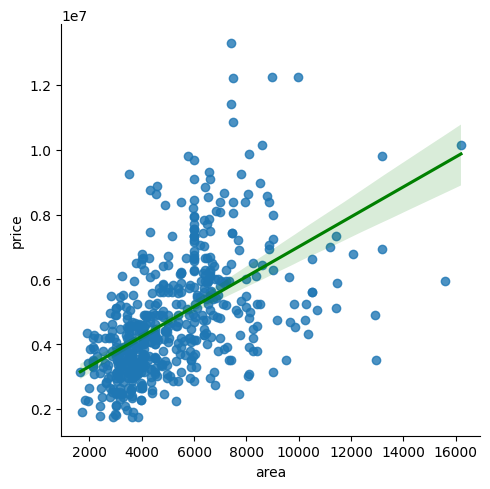

In [84]:
sns.lmplot(data=new_df, x="area", y="price", line_kws={'color': 'green'} ) 
plt.show()

In [85]:
display(df.isna().sum())
display(df.duplicated().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

np.int64(0)

In [86]:
df['area'].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

In [87]:
reg = linear_model.LinearRegression() # getting an instance of the linear model 
reg.fit(df[['area']], df['price']) # df[['area']] = > is independent variable while df['price] => dependent variable(target variable)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### **getting the price of house with a 1650 square feet measurement**

In [88]:
df.loc[df['area'] == 1650]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
449,3150000,1650,3,1,2,no,no,yes,no,no,0,no,unfurnished


In [89]:
y_price_actual = df.loc[df['area'] == 1650]
y_price_actual['price']

449    3150000
Name: price, dtype: int64

#### **predition based on the actual value above**

In [90]:
y_predict = reg.predict([[1650]]) # making prediction

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [108]:
y_predict

array([3149567.05794652])

In [ ]:
residual = y_price_actual['price']  - y_predict # error

In [107]:
print(residual)

449    432.942053
Name: price, dtype: float64


In [92]:
reg.predict([[1651]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3150029.0328408])

In [93]:
reg.predict([[1652]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3150491.00773507])

In [94]:
reg.predict([[165100]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([78659363.52683297])

In [95]:
reg.coef_ # B1

array([461.97489427])

In [96]:
reg.intercept_  # Bo

np.float64(2387308.48239643)

In [97]:
# y = mx + c
2387308.48239643 + (461.97489427*165100)

78659363.52637342

In [110]:
2387308.48239643 + (461.97489427*1650)

3149567.05794193

#### **Multiple Linear Regression**

In [98]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [99]:
m_df = df[['price',	'area',	'bedrooms',	'bathrooms'	,'stories', 'parking']]
m_df.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


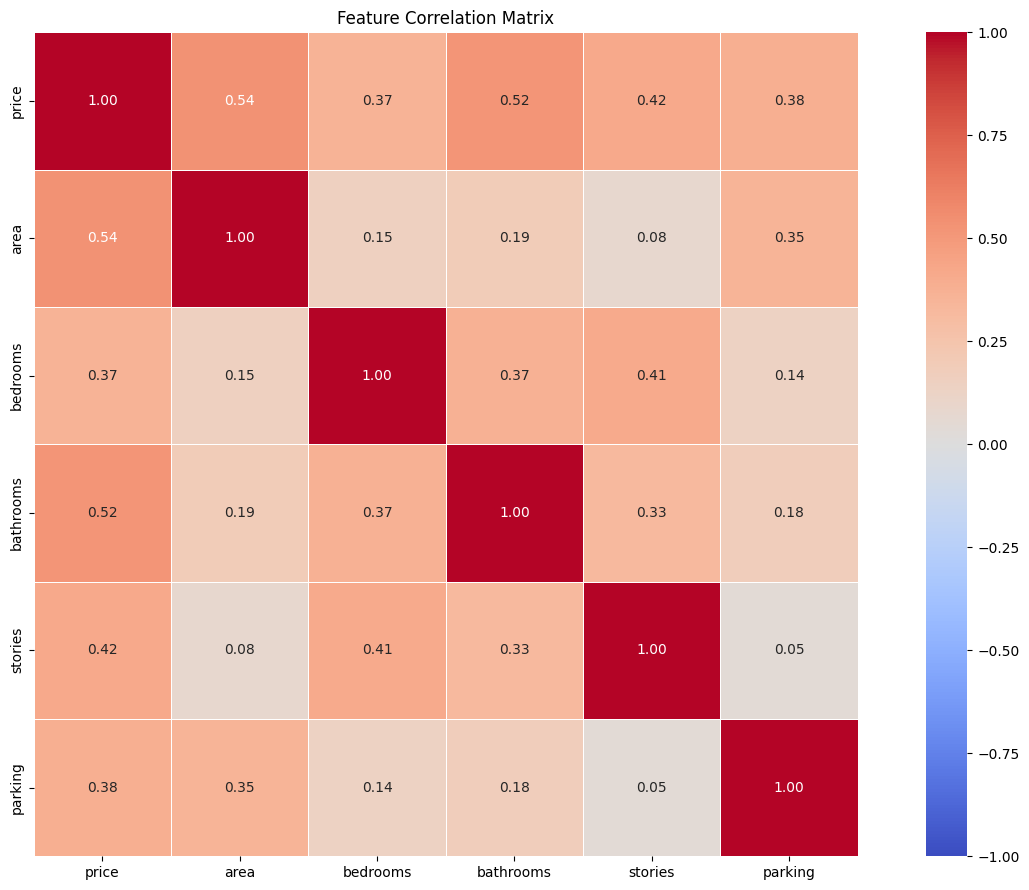

In [100]:
correlation = m_df.corr()
fig = plt.figure(figsize=(14, 9))

sns.heatmap(
    correlation, 
    vmin = -1,
    vmax= 1,
    center = 0, 
    annot = True, 
    fmt = '.2f', 
    cmap = "coolwarm", # red +ve ...  blue-ve
    square = True, 
    linewidths = 0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [118]:
reg = linear_model.LinearRegression() # reinstantiate the linear regression model
reg.fit(m_df[['area','bedrooms', 'bathrooms','stories','parking'	]],m_df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [119]:
m_df.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


In [121]:
reg.predict([[7420,	4,2,3,2 ]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7648873.96926545])

In [122]:
reg.intercept_

np.float64(-145734.4894558806)

In [123]:
reg.coef_

array([3.31115495e+02, 1.67809788e+05, 1.13374016e+06, 5.47939810e+05,
       3.77596289e+05])

#### **Summary:**

- based ont he above predictions, using more than one independent variable, we notice that the error-term is quite large hence why dont we try and include the remianing ctaegorical features to see whethe rit will still behave the same way. 

to include the ctaeogrical columns we need ot perfrom **ENCODING**, here we wil perform :
    - Binary (shines when we have two categories making either 1 or 0 as the ecnoded values)
    - One-hot Encoding (more than 2 categorical types, we do not encode using 1,2,3,4 etc since this will make the model assume it is ordinal)

In [124]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [125]:
cat_columns =[
    'mainroad',	'guestroom',	'basement',	'hotwaterheating',	'airconditioning',	'prefarea',	'furnishingstatus'
] 

df[cat_columns].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished


In [129]:
def checkUnique(df, cols):
    for col in cols: 
        print(f"============[{col}]===============")
        display(df[col].unique()) 

checkUnique(df, cat_columns)

============[mainroad]===============


<StringArray>
['yes', 'no']
Length: 2, dtype: str

============[guestroom]===============


<StringArray>
['no', 'yes']
Length: 2, dtype: str

============[basement]===============


<StringArray>
['no', 'yes']
Length: 2, dtype: str

============[hotwaterheating]===============


<StringArray>
['no', 'yes']
Length: 2, dtype: str

============[airconditioning]===============


<StringArray>
['yes', 'no']
Length: 2, dtype: str

============[prefarea]===============


<StringArray>
['yes', 'no']
Length: 2, dtype: str

============[furnishingstatus]===============


<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

#### **Binary Ecoding**

In [132]:
df_copy = df # making a copy of the original data

In [135]:
df_copy.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished


In [136]:
bin_cat_columns =[
    'mainroad',	'guestroom',	'basement',	'hotwaterheating',	'airconditioning',	'prefarea'
] 

for col in bin_cat_columns:
    df_copy[col] = df_copy[col].map({'yes':1, 'no':0})

In [137]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [139]:
df['furnishingstatus'].unique()

<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

#### **OneHot Encoder**
- Works with more than 2 categoies
- uses formular to encode multiple categories, considering they are not ordinal

In [141]:
df_copy =  pd.get_dummies(df_copy, columns=['furnishingstatus'], drop_first=True)

In [142]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [143]:
df_copy.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='str')

In [146]:
x_independent_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished']

#  extract independent variables
X = df_copy[x_independent_columns]
#  get the y values (outcome value)
y_actual = df_copy['price']

In [147]:
model = linear_model.LinearRegression()
model.fit(X,y_actual)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [150]:
first = X.iloc[[0]]
first

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False


In [154]:
second = X.iloc[[1]]
second

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
1,8960,4,4,4,1,0,0,0,1,3,0,False,False


In [151]:
model.predict(first)

array([8133305.30653281])

In [155]:
model.predict(second)

array([10561027.48030156])

In [156]:
y_predict = model.predict(X) # predicted values based on our data
residuals = y_actual - y_predict # the residuals 

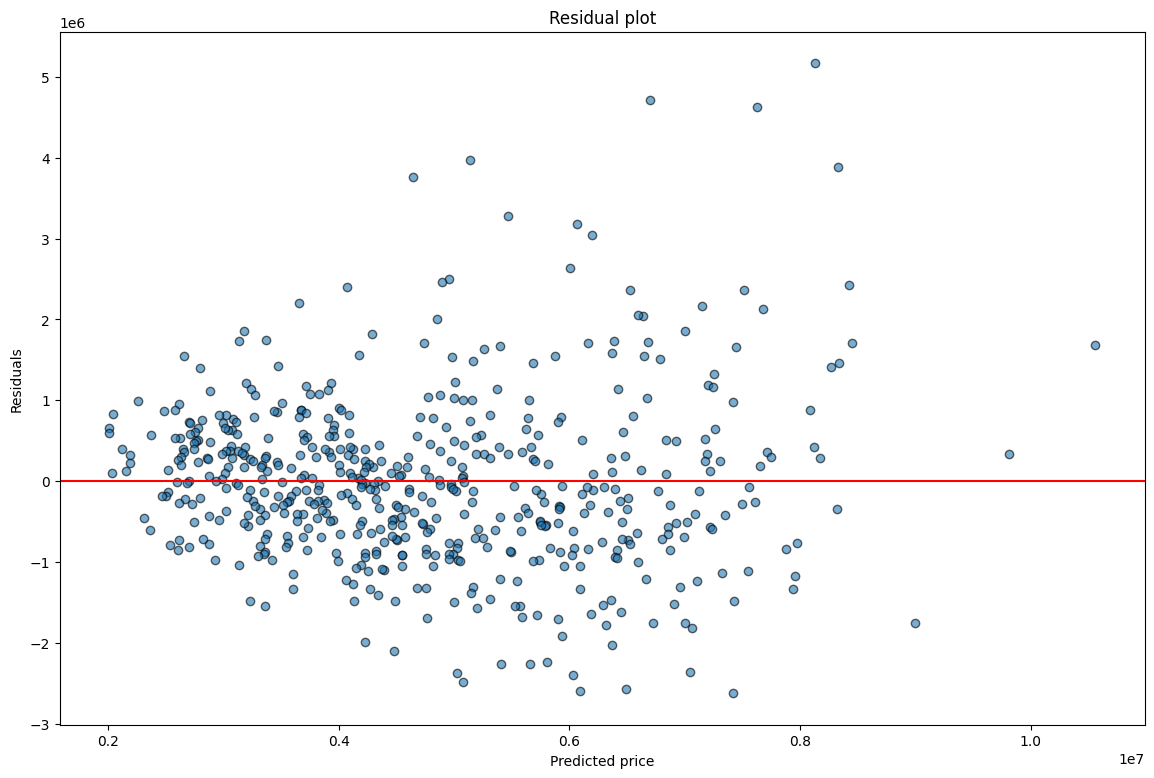

In [160]:
plt.figure(figsize=(14,9))
plt.scatter(y_predict, residuals, alpha=0.6, edgecolors='black')
plt.axhline(color='red')
plt.xlabel('Predicted price')
plt.ylabel('Residuals')
plt.title('Residual plot')
plt.show()

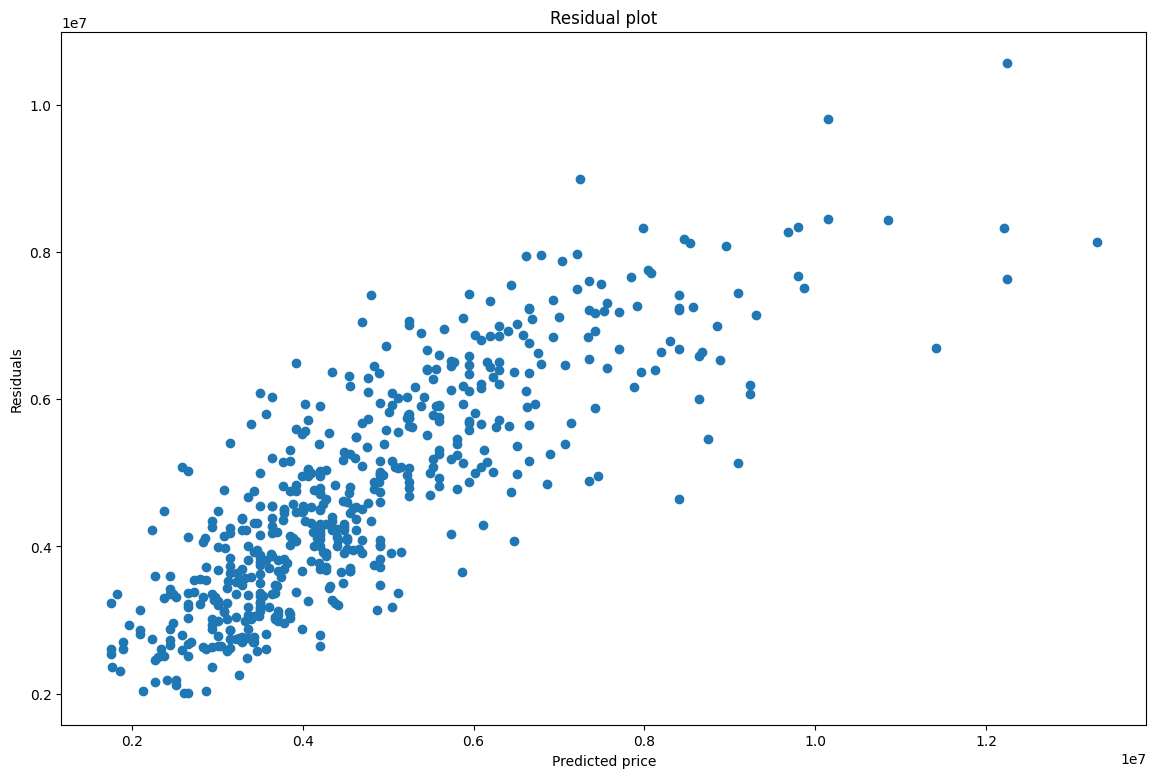

In [164]:
plt.figure(figsize=(14,9))
plt.scatter(y_actual, y_predict)
# plt.plot([y_actual.min(), y_actual.max()],[y_actual.min(), y_actual.max()], 'r--' )
plt.xlabel('Predicted price')
plt.ylabel('Residuals')
plt.title('Residual plot')
plt.show()

In [165]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


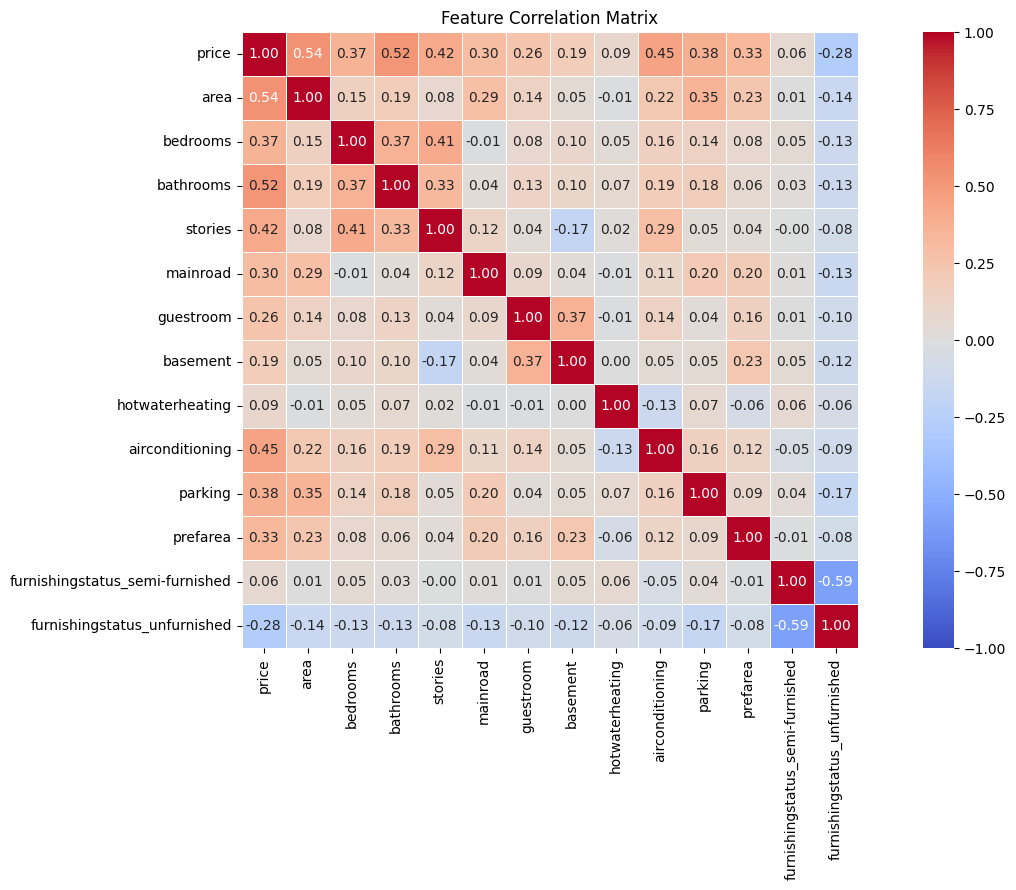

In [166]:
correlation = df_copy.corr()
fig = plt.figure(figsize=(14, 9))

sns.heatmap(
    correlation, 
    vmin = -1,
    vmax= 1,
    center = 0, 
    annot = True, 
    fmt = '.2f', 
    cmap = "coolwarm", # red +ve ...  blue-ve
    square = True, 
    linewidths = 0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Note: 
- positive residueal may indicctae underprediction
- negative residuals may indicate overprediction

**Summary:**

- data is not suitable to fit into a linar model, this has been expressed by one th einaccuracy of the predictions and the residual sizes